In [85]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import keras_tuner as kt
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Input,Dropout
from tensorflow.keras.regularizers import l2

In [62]:
df = pd.read_csv('../data/Final Data/Chl-a/Chl-a-7-day.csv')

In [63]:
df.head()

,Chl-a,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A
0,28.47,0.0147,0.0125,0.0501,0.0725,0.0376,0.0433,0.0251,0.0241,0.0221,0.0206
1,16.77,0.0141,0.0111,0.0511,0.0714,0.0370,0.0363,0.0228,0.0233,0.0197,0.0182
2,14.30,0.0211,0.0192,0.0589,0.0783,0.0433,0.0444,0.0306,0.0312,0.0272,0.0272
3,4.64,0.0152,0.0127,0.0473,0.0532,0.0253,0.0241,0.0192,0.0211,0.0189,0.0176
4,20.48,0.0055,0.0037,0.0536,0.0713,0.0346,0.0344,0.0178,0.0160,0.0156,0.0130


In [64]:
df['Chl-a'] = np.log1p(df['Chl-a'])

In [65]:
Q1 = df['Chl-a'].quantile(0.25)
Q3 = df['Chl-a'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Chl-a'] >= lower_bound) & (df['Chl-a'] <= upper_bound)]

In [66]:
X = df.drop(columns=['Chl-a'])
y = df['Chl-a']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [68]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
input_features = X_train.shape[1]
input_features

10

In [83]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(input_features,)))

    for i in range(hp.Int('num_layers', min_value=1, max_value=10)):
        model.add(
            Dense(
                hp.Int('units' + str(i), min_value=8, max_value=128, step=8),
                activation=hp.Choice('activation' + str(i), values=['relu']),
                kernel_regularizer=l2(0.01)  # Apply L2 regularization
            )
        )
        model.add(Dropout(hp.Choice('dropout' + str(i), values=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.9])))

    model.add(Dense(1, activation='linear'))  # Output layer (Regression task)

    optimizer = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop', 'adadelta'])
    
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae', 'mse'])
    return model

In [86]:
final_tuner = kt.RandomSearch(build_model,
                              objective='val_loss',
                              max_trials=10,
                             directory='new_directory',
                             project_name='final_tuner')

In [87]:
final_tuner.search(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

Trial 10 Complete [00h 00m 01s]
val_loss: 0.17078661918640137

Best val_loss So Far: 0.0474107600748539
Total elapsed time: 00h 00m 17s


In [88]:
final_tuner.get_best_hyperparameters()[0].values

{'num_layers': 1,
 'units0': 64,
 'activation0': 'relu',
 'dropout0': 0.6,
 'optimizer': 'rmsprop',
 'units1': 80,
 'activation1': 'relu',
 'dropout1': 0.5,
 'units2': 48,
 'activation2': 'relu',
 'dropout2': 0.6,
 'units3': 48,
 'activation3': 'relu',
 'dropout3': 0.1,
 'units4': 40,
 'activation4': 'relu',
 'dropout4': 0.9,
 'units5': 8,
 'activation5': 'relu',
 'dropout5': 0.2,
 'units6': 40,
 'activation6': 'relu',
 'dropout6': 0.4,
 'units7': 88,
 'activation7': 'relu',
 'dropout7': 0.9,
 'units8': 8,
 'activation8': 'relu',
 'dropout8': 0.6,
 'units9': 16,
 'activation9': 'relu',
 'dropout9': 0.2}

In [74]:
final_model = final_tuner.get_best_models(num_models=1)[0]
final_model.summary()

/Users/kavyasmac/anaconda3/envs/new_env/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 88)             │         1,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 88)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            89 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,761 (6.88 KB)

 Trainable params: 1,761 (6.88 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
history = final_model.fit(X_train,y_train,epochs=280,initial_epoch=11,validation_data=(X_test,y_test))

Epoch 12/280
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - loss: 0.0435 - mae: 0.1572 - mse: 0.0435 - val_loss: 0.0327 - val_mae: 0.1202 - val_mse: 0.0327
Epoch 13/280
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - loss: 0.0452 - mae: 0.1590 - mse: 0.0452 - val_loss: 0.0312 - val_mae: 0.1117 - val_mse: 0.0312
Epoch 14/280
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - loss: 0.0412 - mae: 0.1513 - mse: 0.0412 - val_loss: 0.0305 - val_mae: 0.1127 - val_mse: 0.0305
Epoch 15/280
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - loss: 0.0426 - mae: 0.1526 - mse: 0.0426 - val_loss: 0.0299 - val_mae: 0.1105 - val_mse: 0.0299
Epoch 16/280
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - loss: 0.0441 - mae: 0.1564 - mse: 0.0441 - val_loss: 0.0301 - val_mae: 0.1139 - val_mse: 0.0301
Epoch 17/280
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 0.0423 - mae: 0.1514 - mse: 0.0423 - val_loss: 0.0301 - val_mae: 0.1177 - val_mse: 0.0301
Epoch 18/280
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - loss: 0.0414 - mae: 0.1509 - mse

In [89]:
loss, mae, mse = final_model.evaluate(X_test, y_test)
print(f"Test MAE: {mae}")
print(f"Test MSE: {mse}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 366us/step - loss: 0.0171 - mae: 0.0920 - mse: 0.0171
Test MAE: 0.09432011097669601
Test MSE: 0.01727522723376751


In [90]:
y_pred = final_model.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step


In [91]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [92]:
mae = mean_absolute_error(y_test,y_pred)
mae = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [93]:
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2_Score: {r2}")
print(f"RMSE: {np.sqrt(mse)}")

MAE: 0.017275228525626886
MSE: 0.01727522723376751
R2_Score: 0.6376300739980367
RMSE: 0.1314352587160976


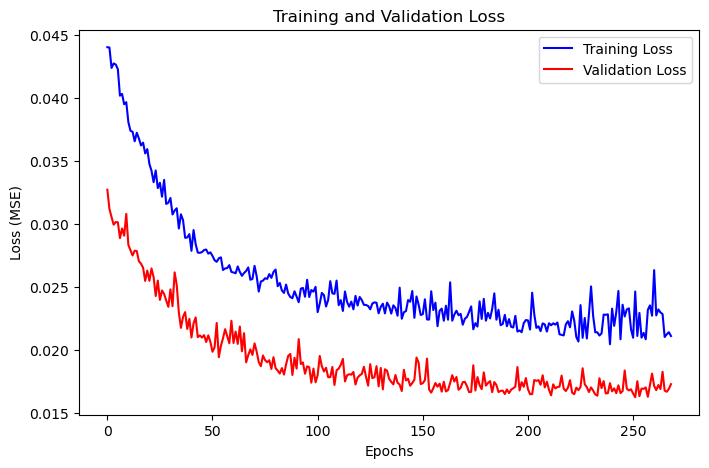

In [94]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])